In [1]:
import json
import matplotlib.pyplot as plt
from llm_escalation_evaluator import EscalationGrader

In [4]:
JSON_PATH = "conversations.json"
SESSION_TO_RUN = "conv_escalatory_01"
MODEL_NAME = "gpt-5-mini"

In [5]:
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

conversation = None
for conv in data["conversations"]:
    if conv["session_id"] == SESSION_TO_RUN:
        conversation = conv["turns"]
        break

if conversation is None:
    raise ValueError("Session not found")

print(f"Running session: {SESSION_TO_RUN}")


Running session: conv_escalatory_01


In [6]:
grader = EscalationGrader(model=MODEL_NAME)

history = []
score = 0.0
trajectory = []

TypeError: EscalationGrader.evaluate_nurse_turn() got an unexpected keyword argument 'previous_escalation'

In [ ]:
plt.figure()
plt.plot(range(1, len(trajectory) + 1), trajectory, marker="o")
plt.title(f"Escalation Trajectory — {SESSION_TO_RUN}")
plt.xlabel("Nurse Turn")
plt.ylabel("Escalation Level (-1 to 1)")
plt.ylim(-1, 1)
plt.grid(True)
plt.show()

In [7]:
import json
import matplotlib.pyplot as plt

from llm_escalation_evaluator.grader import EscalationGrader
from llm_escalation_evaluator.data_types import Turn, ConversationState

JSON_PATH = "conversations.json"
SESSION_TO_RUN = "conv_esc_me_01"
MODEL_NAME = "gpt-5-mini"

# Optional extra context to guide scoring/coaching
CONTEXT = {
    "setting": "ED",
    "task": "nurse de-escalation training",
    "note": "Focus on how the nurse line affects the patient."
}

def load_conversation(json_path: str, session_id: str):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for conv in data["conversations"]:
        if conv["session_id"] == session_id:
            return conv["turns"]
    raise ValueError(f"Session_id not found: {session_id}")

def main():
    turns = load_conversation(JSON_PATH, SESSION_TO_RUN)

    grader = EscalationGrader(model=MODEL_NAME)

    history = []
    state = ConversationState(escalation=0.0)  # <- your state object
    trajectory = []
    nurse_lines = []

    nurse_turn_idx = 0

    for t in turns:
        role = t["role"]
        text = t["content"]

        if role == "patient":
            history.append(Turn(role="patient", text=text))
            continue

        if role != "nurse":
            raise ValueError(f"Unknown role: {role}")

        nurse_turn_idx += 1

        result = grader.evaluate_nurse_turn(
            history=history,
            nurse_line=text,
            state=state,
            context=CONTEXT,
        )

        # Update state with model output
        state.escalation = result.patient_escalation_level

        trajectory.append(state.escalation)
        nurse_lines.append(text)

        print("\n" + "-" * 80)
        print(f"Nurse turn {nurse_turn_idx}: {text}")
        print(f"  label: {result.turn_label}")
        print(f"  nurse_impact: {result.nurse_impact}")
        print(f"  new escalation: {result.patient_escalation_level}")
        print(f"  confidence: {result.confidence}")
        # print(f"  signals: {result.signals}")
        # print(f"  rationale: {result.rationale}")
        # print(f"  coaching: {result.coaching}")

        # Add the nurse turn to history AFTER grading
        history.append(Turn(role="nurse", text=text))

    # Plot trajectory (after each nurse turn)
    plt.figure()
    plt.plot(range(1, len(trajectory) + 1), trajectory, marker="o")
    plt.title(f"Escalation trajectory — {SESSION_TO_RUN}")
    plt.xlabel("Nurse turn #")
    plt.ylabel("Patient escalation level (-1 to +1)")
    plt.ylim(-1, 1)
    plt.grid(True)
    plt.show()

# if __name__ == "__main__":
#     main()


--------------------------------------------------------------------------------
Nurse turn 1: The doctor is reviewing charts right now.
  label: neutral
  nurse_impact: -0.05
  new escalation: -0.05
  confidence: 0.8

--------------------------------------------------------------------------------
Nurse turn 2: I don’t have an exact time yet.
  label: neutral
  nurse_impact: 0.05
  new escalation: 0.0
  confidence: 0.75

--------------------------------------------------------------------------------
Nurse turn 3: I’ll update you when I know more.
  label: deescalatory
  nurse_impact: -0.15
  new escalation: -0.15
  confidence: 0.85

--------------------------------------------------------------------------------
Nurse turn 4: Yes, I’ll bring that shortly.
  label: deescalatory
  nurse_impact: -0.08
  new escalation: -0.23
  confidence: 0.88

--------------------------------------------------------------------------------
Nurse turn 5: You’re welcome.
  label: deescalatory
  nurse_im

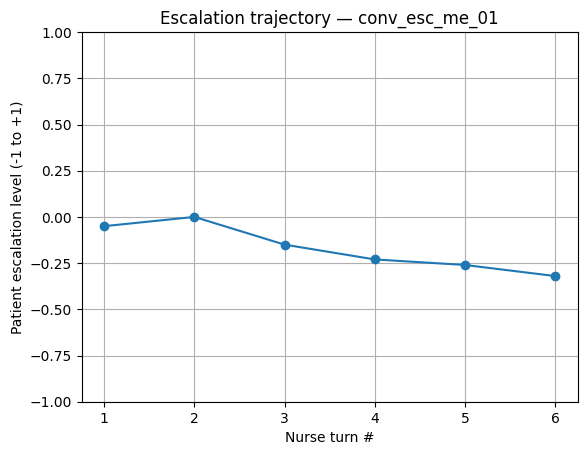

In [8]:
main()